# Communicating Molecular Structure And Orientation Via Markdown

In this notebook we demonstrate how the `chemistree` interface enables agents to understand chemical structure.

In [1]:
from rdkit import Chem

from chemistree import DesignSession

# Example Structures
MOLECULE = "../tests/data/abl1/reference.sdf"
RECEPTOR = "../tests/data/abl1/receptor.pdb"

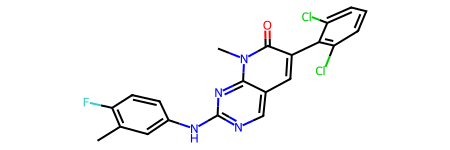

In [2]:
ligand = Chem.MolFromMolFile(MOLECULE, removeHs=False)
receptor = Chem.MolFromPDBFile(RECEPTOR, removeHs=False, sanitize=False)
ligand

The `describe` method generates a markdown summary of the molecules fragment group tree. The fragment group tree is defined by the set of fragmentable bonds. A bond is fragmentable if it is single, acyclic, and either endpoint is a ring atom or the bond is a functional-group boundary (exactly one endpoint inside a matched group). Bonds internal to a recognized functional group are kept, so groups like esters and amides stay intact as single, named units.

Each fragment is given an index `[i]`, a common name, SMILES (including ports), molecular formula, designation (scaffold or leaf), and a list of attached fragments (high level connectivity).

In [3]:
ds = DesignSession(ligand)
print(ds.describe())

# Group Summary
Call describe_group(id) for a group's atom positions, rings, and topology.

- [0] heteroaromatic `[2*]n1c(=O)c([7*])c([H])c2c([H])nc([8*])nc21` (C7H2N3O) — scaffold, attached to [5] methyl, [2] benzene, [3] amine
- [1] benzene `[1*]c1c([4*])c([H])c([H])c([3*])c1[H]` (C6H3) — scaffold, attached to [4] methyl, [3] amine, [6] fluoro
- [2] benzene `[5*]c1c([7*])c([6*])c([H])c([H])c1[H]` (C6H3) — scaffold, attached to [7] chloro, [8] chloro, [0] heteroaromatic
- [3] amine `[3*]N([8*])[H]` (HN) — scaffold, attached to [1] benzene, [0] heteroaromatic
- [4] methyl `[1*]C([H])([H])[H]` (CH3) — leaf, attached to [1] benzene
- [5] methyl `[2*]C([H])([H])[H]` (CH3) — leaf, attached to [0] heteroaromatic
- [6] fluoro `[4*]F` (F) — leaf, attached to [1] benzene
- [7] chloro `[5*]Cl` (Cl) — leaf, attached to [2] benzene
- [8] chloro `[6*]Cl` (Cl) — leaf, attached to [2] benzene

**Properties:** MW 429, cLogP 5.5, TPSA 60, HBD 1, HBA 4, RotB 3, aromatic rings 4, Fsp3 0.10, formal charg

Each fragment group can be further inspected further using the `describe_group` method to determine the connectivity patterns in natural language. An atom map is provided for easy editing and then used to define rings and heavy atom relative positions. Heavy atom substitution patterns are communicated for each index as `atom j`, common name for atom type, attached hydrogen indices, and the identity of neighbors up to a specified `radius`.

In [4]:
print(ds.describe_group(0, radius=2))

## [0] heteroaromatic `[2*]n1c(=O)c([7*])c([H])c2c([H])nc([8*])nc21` (C7H2N3O) — scaffold, attached to [5] methyl, [2] benzene, [3] amine
Atom ids are `:k` (use as grow/mutate position_id); `[n*]` = port (connects groups).
Positions: each heavy atom lists nearby atoms as ortho/meta/para (same aromatic ring) or alpha/beta/gamma (greek, by bond count); `id·[n*]` marks an atom bearing a port. Grow at a listed hydrogen id; mutate a heavy-atom id.

**Atom Map:** `[c:0]1([H:11])[c:2]2[c:1]([H:12])[n:7][c:6]([8*])[n:8][c:4]2[n:9]([2*])[c:5](=[O:10])[c:3]1[7*]`
**Rings:**
- Ring A (6-membered): atoms 0, 2, 3, 4, 5, 9
- Ring B (6-membered): atoms 1, 2, 4, 6, 7, 8
**Positions:**
- atom 0 (aromatic C, H 11) — ortho: 2, 3·[7*] benzene; meta: 4, 5; beta: 1
- atom 1 (aromatic C, H 12) — ortho: 2, 7; meta: 4, 6·[8*] amine; beta: 0
- atom 2 (aromatic C) — ortho: 0, 1, 4; meta: 3·[7*] benzene, 7, 8, 9·[2*] methyl
- atom 3 (aromatic C, bears [7*] benzene) — ortho: 0, 5; meta: 2, 9·[2*] methyl; beta: 10


When a receptor is provided the output of `describe` is augmented with a predicted affinity (Vinardo score) which agents can use to understand if a modification is expected to positively or negatively impact binding.

In [5]:
ds = DesignSession(ligand, receptor=receptor)
print(ds.describe())

# Group Summary
Call describe_group(id) for a group's atom positions, rings, and topology.

- [0] heteroaromatic `[2*]n1c(=O)c([7*])c([H])c2c([H])nc([8*])nc21` (C7H2N3O) — scaffold, attached to [5] methyl, [2] benzene, [3] amine
- [1] benzene `[1*]c1c([4*])c([H])c([H])c([3*])c1[H]` (C6H3) — scaffold, attached to [4] methyl, [3] amine, [6] fluoro
- [2] benzene `[5*]c1c([7*])c([6*])c([H])c([H])c1[H]` (C6H3) — scaffold, attached to [7] chloro, [8] chloro, [0] heteroaromatic
- [3] amine `[3*]N([8*])[H]` (HN) — scaffold, attached to [1] benzene, [0] heteroaromatic
- [4] methyl `[1*]C([H])([H])[H]` (CH3) — leaf, attached to [1] benzene
- [5] methyl `[2*]C([H])([H])[H]` (CH3) — leaf, attached to [0] heteroaromatic
- [6] fluoro `[4*]F` (F) — leaf, attached to [1] benzene
- [7] chloro `[5*]Cl` (Cl) — leaf, attached to [2] benzene
- [8] chloro `[6*]Cl` (Cl) — leaf, attached to [2] benzene

**Properties:** MW 429, cLogP 5.5, TPSA 60, HBD 1, HBA 4, RotB 3, aromatic rings 4, Fsp3 0.10, formal charg

The `distance` method communicates how close each group is to a specified residue. A summary table shows each groups minimum distance and a details section shows the distance for each atom in each group.

In [6]:
print(ds.distance("TYR21"))

# Distances to TYR21

| group | min distance (A) |
|---|---|
| [5] methyl | 3.20 |
| [0] heteroaromatic | 3.97 |
| [1] benzene | 4.37 |
| [6] fluoro | 5.70 |
| [3] amine | 6.58 |
| [2] benzene | 6.80 |
| [7] chloro | 6.86 |
| [8] chloro | 7.23 |
| [4] methyl | 7.73 |

## Details
### [5] methyl
- atom 0 (C): 3.20
### [0] heteroaromatic
- atom 0 (C): 7.24
- atom 1 (C): 7.89
- atom 2 (C): 6.88
- atom 3 (C): 6.20
- atom 4 (C): 5.55
- atom 5 (C): 4.89
- atom 6 (C): 6.43
- atom 7 (N): 7.63
- atom 8 (N): 5.35
- atom 9 (N): 4.66
- atom 10 (O): 3.97
### [1] benzene
- atom 0 (C): 4.52
- atom 1 (C): 4.37
- atom 2 (C): 6.80
- atom 3 (C): 6.57
- atom 4 (C): 5.87
- atom 5 (C): 5.51
### [6] fluoro
- atom 0 (F): 5.70
### [3] amine
- atom 0 (N): 6.58
### [2] benzene
- atom 0 (C): 7.62
- atom 1 (C): 7.66
- atom 2 (C): 7.34
- atom 3 (C): 7.15
- atom 4 (C): 7.03
- atom 5 (C): 6.80
### [7] chloro
- atom 0 (Cl): 6.86
### [8] chloro
- atom 0 (Cl): 7.23
### [4] methyl
- atom 0 (C): 7.73


The `contacts` method returns a summary of the closest group atom and corresponding distance for each residue within a specified distance of the ligand.

In [7]:
print(ds.contacts(dist_cutoff=4.5))

# Binding-site contacts (within 4.5 A)

| residue | group | closest atom | distance (A) |
|---|---|---|---|
| MET86 | [0] heteroaromatic | atom 7 (N) | 2.00 |
| THR83 | [0] heteroaromatic | atom 0 (C) | 2.59 |
| ASP149 | [7] chloro | atom 0 (Cl) | 2.60 |
| TYR21 | [5] methyl | atom 0 (C) | 3.20 |
| GLU84 | [0] heteroaromatic | atom 1 (C) | 3.30 |
| PHE150 | [7] chloro | atom 0 (Cl) | 3.32 |
| TYR88 | [4] methyl | atom 0 (C) | 3.35 |
| GLY89 | [1] benzene | atom 3 (C) | 3.42 |
| LEU138 | [0] heteroaromatic | atom 4 (C) | 3.43 |
| ALA37 | [0] heteroaromatic | atom 1 (C) | 3.44 |
| GLY17 | [6] fluoro | atom 0 (F) | 3.49 |
| LYS39 | [8] chloro | atom 0 (Cl) | 3.50 |
| ALA148 | [7] chloro | atom 0 (Cl) | 3.52 |
| VAL24 | [0] heteroaromatic | atom 10 (O) | 3.68 |
| PHE85 | [1] benzene | atom 2 (C) | 3.73 |
| MET58 | [2] benzene | atom 1 (C) | 3.74 |
| ILE81 | [2] benzene | atom 2 (C) | 3.78 |
| VAL38 | [8] chloro | atom 0 (Cl) | 3.80 |
| THR87 | [4] methyl | atom 0 (C) | 3.90 |
| VAL67 | [7]